In [75]:
import numpy as np
import pandas as pd;
# data processing
labdata =pd.read_csv('Labresults-100 (1).csv');
outcome = pd.read_csv('Outcomes (1).csv');
patnt = pd.read_csv('Patients-50.csv');
diagno = pd.read_csv('Diagnoses.csv');

In [76]:
patnt =patnt.merge(diagno, on='DiagnosisID')
patnt = patnt.merge(outcome, on='OutcomeID')

In [77]:
patnt['AdmissionDate'] = pd.to_datetime(patnt['AdmissionDate'])

patnt['DischargeDate'] = pd.to_datetime(patnt['DischargeDate'])
patnt['stayfrom'] = (patnt['DischargeDate'] -patnt['AdmissionDate']).dt.days

In [78]:
patnt['OutcomeName'] = patnt['OutcomeName'].str.strip().str.title()

In [79]:

outcome_map = {
    'Recovered': 0,
    'Stable': 1,
    'Deceased': 1,
    'Ongoing': 0
}

patnt['Outcome'] = patnt['OutcomeName'].map(outcome_map)

In [80]:
print(patnt['Outcome'].value_counts(dropna=False))

Outcome
0    35
1    15
Name: count, dtype: int64


In [81]:
patnt['High_Risk_Indicator'] = np.where(
    (patnt['Age'] > 65) |
    (patnt['OutcomeName'].isin(['complicated', 'deceased'])),1,0
)

In [82]:
abnormal_conditions = {
    'Glucose Fasting': lambda x: x > 120,
    'Cholesterol': lambda x: x > 200,
    'Hemoglobin': lambda x: x < 13,
    'Creatinine': lambda x: x > 1.2,
    'TSH': lambda x: x < 0.4,
    'Vitamin D': lambda x: x < 30,
    'Sodium': lambda x: x < 135,
    'Potassium': lambda x: (x < 3.5) or (x > 5.1),
    'WBC Count': lambda x: (x < 4) or (x > 11),
    'RBC Count': lambda x: (x < 4.5) or (x > 5.9)
}


def count_abnormal_labs(patient_id):
    patient_labs = labdata[labdata['PatientID'] == patient_id]

    count = 0

    for test_name, condition in abnormal_conditions.items():

        test_results = patient_labs[
            patient_labs['TagName'] == test_name
        ]

        for value in test_results['Result']:
            if condition(value):
                count += 1

    return count

In [83]:
patnt['AbnormalLabCount'] = patnt['PatientID'].apply(
    count_abnormal_labs
)

In [85]:
# lab count bata rah hai
print(patnt['AbnormalLabCount'].describe())
print(
    patnt[['PatientID', 'AbnormalLabCount']]
    .sort_values('AbnormalLabCount', ascending=False)
    .head(10)
)

count    50.000000
mean      0.880000
std       1.023001
min       0.000000
25%       0.000000
50%       1.000000
75%       1.000000
max       5.000000
Name: AbnormalLabCount, dtype: float64
    PatientID  AbnormalLabCount
20         21                 5
1           2                 3
39         40                 3
4           5                 2
8           9                 2
36         37                 2
33         34                 2
30         31                 2
41         42                 2
5           6                 2


In [103]:
# Features and target
features = ['Age', 'stayfrom', 'TreatmentCost', 'AbnormalLabCount']
target = 'Outcome'

X = patnt[features]
y = patnt[target]


# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)


# Logistic Regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)


# Prediction

y_pred = model.predict(X_test)


# Accuracy

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7333333333333333


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

model_scaled = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    )
)

model_scaled.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [88]:
model = LogisticRegression(max_iter=1000)

model.fit(X, y)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [89]:
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

importance['Absolute_Importance'] = (
    importance['Coefficient'].abs()
)

importance = importance.sort_values(
    by='Absolute_Importance',
    ascending=False
)

print(importance)

            Feature  Coefficient  Absolute_Importance
3  AbnormalLabCount    -0.331981             0.331981
0               Age     0.014669             0.014669
1          stayfrom    -0.006138             0.006138
2     TreatmentCost    -0.000010             0.000010


In [90]:
import matplotlib.pyplot as plt

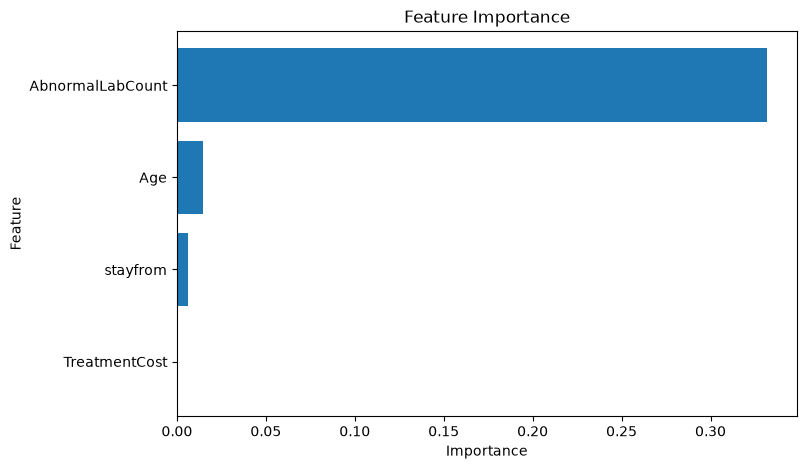

In [91]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance['Feature'],
    importance['Absolute_Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')

plt.gca().invert_yaxis()

plt.show()

In [104]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

model_scaled = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

model_scaled.fit(X, y)

print("Model trained successfully!")

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

f1_scores = cross_val_score(
    model_scaled,
    X,
    y,
    cv=cv,
    scoring='f1'
)

accuracy_scores = cross_val_score(
    model_scaled,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print("F1 Scores:", f1_scores)
print("Average F1:", f1_scores.mean())

print("Accuracy Scores:", accuracy_scores)
print("Average Accuracy:", accuracy_scores.mean())

Model trained successfully!
F1 Scores: [0. 0. 0. 0. 0.]
Average F1: 0.0
Accuracy Scores: [0.7 0.6 0.7 0.7 0.7]
Average Accuracy: 0.6799999999999999


In [102]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model_scaled = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    )
)

model_scaled.fit(X, y)

print("New model trained successfully!")

New model trained successfully!


In [94]:
coef = model_scaled.named_steps['logisticregression'].coef_[0]

for feature, value in zip(features, coef):
    print(feature, ":", value)

Age : 0.24194334005490786
stayfrom : -0.28271928926447853
TreatmentCost : -0.17503543740539892
AbnormalLabCount : -0.3271655819621901


In [101]:
import joblib

joblib.dump(model_scaled, 'risk_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [105]:
print(
    patnt.groupby('Outcome')[
        ['Age', 'stayfrom', 'TreatmentCost', 'AbnormalLabCount']
    ].mean()
)
print(
    patnt.groupby('Outcome').size()
)



               Age    stayfrom  TreatmentCost  AbnormalLabCount
Outcome                                                        
0        51.314286  109.600000   38135.500571          0.942857
1        54.866667   93.666667   34148.462667          0.733333
Outcome
0    35
1    15
dtype: int64


In [106]:
print(
    patnt[patnt['Outcome'] == 1][
        ['PatientID', 'Age', 'stayfrom',
         'TreatmentCost', 'AbnormalLabCount']
    ].sort_values('Age', ascending=False)
)

    PatientID  Age  stayfrom  TreatmentCost  AbnormalLabCount
28         29   75        35       31571.15                 1
46         47   75       173       68026.72                 0
5           6   68        66       41738.99                 2
12         13   67        91       10603.74                 1
44         45   65        21       48803.05                 1
7           8   59       183       63547.10                 0
21         22   58        90       16169.10                 0
14         15   56       130       44639.25                 0
32         33   54       136       34897.55                 1
38         39   48        35        7047.40                 1
35         36   44        18       20238.24                 0
8           9   43       135       62811.37                 2
40         41   40       213        8766.01                 0
4           5   39        30       28993.99                 2
2           3   32        49       24373.28                 0


In [107]:
patient_6 = patnt[patnt['PatientID'] == 6][features]

print(patient_6)

print("Actual Outcome:",
      patnt.loc[patnt['PatientID'] == 6, 'Outcome'].values[0])

print("Predicted Outcome:",
      model_scaled.predict(patient_6)[0])

print("Probability:",
      model_scaled.predict_proba(patient_6)[0][1])

   Age  stayfrom  TreatmentCost  AbnormalLabCount
5   68        66       41738.99                 2
Actual Outcome: 1
Predicted Outcome: 0
Probability: 0.2959160169551087


In [108]:
# Har patient ke liye individual abnormal lab features

def get_lab_features(patient_id):
    patient_labs = labdata[labdata['PatientID'] == patient_id]

    features = {
        'HighGlucose': 0,
        'HighCholesterol': 0,
        'LowHemoglobin': 0,
        'HighCreatinine': 0,
        'AbnormalTSH': 0,
        'LowVitaminD': 0,
        'AbnormalSodium': 0,
        'AbnormalPotassium': 0,
        'AbnormalWBC': 0,
        'AbnormalRBC': 0
    }

    for _, row in patient_labs.iterrows():

        test = row['TagName']
        value = row['Result']

        if test == 'Glucose Fasting' and value > 120:
            features['HighGlucose'] = 1

        elif test == 'Cholesterol' and value > 200:
            features['HighCholesterol'] = 1

        elif test == 'Hemoglobin' and value < 13:
            features['LowHemoglobin'] = 1

        elif test == 'Creatinine' and value > 1.2:
            features['HighCreatinine'] = 1

        elif test == 'TSH' and value < 0.4:
            features['AbnormalTSH'] = 1

        elif test == 'Vitamin D' and value < 30:
            features['LowVitaminD'] = 1

        elif test == 'Sodium' and value < 135:
            features['AbnormalSodium'] = 1

        elif test == 'Potassium' and (value < 3.5 or value > 5.1):
            features['AbnormalPotassium'] = 1

        elif test == 'WBC Count' and (value < 4 or value > 11):
            features['AbnormalWBC'] = 1

        elif test == 'RBC Count' and (value < 4.5 or value > 5.9):
            features['AbnormalRBC'] = 1

    return pd.Series(features)


lab_features = patnt['PatientID'].apply(get_lab_features)

patnt = pd.concat(
    [patnt.reset_index(drop=True),
     lab_features.reset_index(drop=True)],
    axis=1
)

print(patnt.head())

print(patnt[
    ['PatientID',
     'HighGlucose',
     'HighCholesterol',
     'LowHemoglobin',
     'HighCreatinine',
     'AbnormalTSH',
     'LowVitaminD',
     'AbnormalSodium',
     'AbnormalPotassium',
     'AbnormalWBC',
     'AbnormalRBC']
].head(10))

   PatientID          Name  Age  Gender  DiagnosisID AdmissionDate  \
0          1     Ali Ahmed   23    Male            4    2026-04-20   
1          2    Neha Rahul   61  Female            2    2026-07-09   
2          3   Faizan John   32    Male            3    2026-07-03   
3          4  Fatima Mohit   64  Female            2    2026-06-14   
4          5     Aman Zoya   39    Male            1    2026-07-02   

  DischargeDate  OutcomeID  TreatmentCost DiagnosisName  ... HighGlucose  \
0    2026-08-30          1       50120.03      COVID-19  ...           0   
1    2026-08-27          1       26537.15  Hypertension  ...           1   
2    2026-08-21          3       24373.28        Asthma  ...           0   
3    2026-07-28          2       53329.13  Hypertension  ...           0   
4    2026-08-01          3       28993.99      Diabetes  ...           1   

   HighCholesterol  LowHemoglobin  HighCreatinine  AbnormalTSH  LowVitaminD  \
0                0              0          

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score
)

features = [
    'Age',
    'stayfrom',
    'TreatmentCost',
    'HighGlucose',
    'HighCholesterol',
    'LowHemoglobin',
    'HighCreatinine',
    'AbnormalTSH',
    'LowVitaminD',
    'AbnormalSodium',
    'AbnormalPotassium',
    'AbnormalWBC',
    'AbnormalRBC'
]

X = patnt[features]
y = patnt['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

model_new = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        class_weight='balanced'
    )
)

model_new.fit(X_train, y_train)

y_pred = model_new.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.5333333333333333

Confusion Matrix:
[[8 3]
 [4 0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.73      0.70        11
           1       0.00      0.00      0.00         4

    accuracy                           0.53        15
   macro avg       0.33      0.36      0.35        15
weighted avg       0.49      0.53      0.51        15

F1 Score: 0.0
